In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import transport.dispersion as dispersion
import transport.orbitcreation as orbitcreation
import transport.conductivity as conductivity
from transport.makesigmalist import makelist_parallel,makelist_serial
from time import time

In [ ]:
class params24:
    #(Tzmultvalue,invtau_iso,strength,spread_xy,spread_z,n)
    params35 = (0.03440039775905757,10.067520224261962,263803.676305314,0.13198896044913613,4.371680458121389)
    params30 = (0.033369871920650995,9.0583774685104,564393.5399989765,0.13598510117993956,5.1668009899239635)
    params25 = (0.03189647980237115,7.873773300105872,712719.5316268859,0.13954769682275667,5.798434445945669)
    params20 = (0.03148530912809664,7.267009029215178,1110869.5887609161,0.14425692694831663,7.389590020484316)

    paramslist = np.array([params20,params25,params30,params35])
    thetamax = [99,99,99,60]
    sample = "2511A"


In [3]:
def create_data_24(params):

    starttime_global = time()
    thetalist = np.linspace(-14,99,40)

    res_z = 20
    res_xy = 100

    mumultvalue=0.81

    Tzmultvalue,invtau_iso,strength,spread_xy,n = params

    plotScattering=False

    dispersionInstance = dispersion.LSCOdispersion(T= 190e-3,T1multvalue=-0.132,T11multvalue=0.066,Tzmultvalue=Tzmultvalue,mumultvalue=mumultvalue)
    FSorbitsInstance = orbitcreation.fermiSurfaceOrbits(res_z,res_xy,dispersionInstance,True)
    starttime = time()
    FSorbitsInstance.createFS(tilingformat="variable",alpha=0.1,parallelised=False)
    endtime = time()
    print(f"Time taken to create Fermi Surface = {endtime - starttime}")
    print(f"Doping={FSorbitsInstance.calculateDoping()}")

    def create_rhozz(phi,Bmag,scattering_in=True):
        phi_rad = np.deg2rad(phi)
        conductivityInstance = conductivity.Conductivity(dispersionInstance,FSorbitsInstance,invtau_iso=invtau_iso,delta_in_k=True)
        starttime = time()
        conductivityInstance.createAmatrix_Bindependent_isotropic()
        conductivityInstance.create_Hfunc(scatteringmodel="pipidelta",strength=strength,spread_xy=spread_xy,n=n)
        conductivityInstance.createAmatrix_Bindependent_fwdscatter_out()
        if scattering_in: conductivityInstance.createAmatrix_Bindependent_fwdscatter_in()
        endtime = time()
        print(f"Time taken to create B independent Amatrix =  {endtime - starttime}")

        def getsigma(theta,Bmag=Bmag):
            B = [Bmag*np.sin(np.deg2rad(theta))*np.cos(phi_rad),Bmag*np.sin(np.deg2rad(theta))*np.sin(phi_rad),Bmag*np.cos(np.deg2rad(theta))]
            conductivityInstance.createAmatrix_Bdependent(B)
            conductivityInstance.createAlpha()
            conductivityInstance.createSigma()

            #print(f"Theta={theta}. Calculated total area: {conductivityInstance.areasum}. Number of orbits used {len(conductivityInstance.FSorbitsInstance.FSorbits)}. Size of Amatrix: {conductivityInstance.n}")
            return conductivityInstance.sigma,conductivityInstance.areasum


        sigmalist,rholist,arealist = makelist_parallel(getsigma,thetalist)
        #sigma_zero,area_zero = getsigma(theta=0,Bmag=0)
        #sigma_9T,area_9T = getsigma(theta=0,Bmag=9)

        #rho_zero = np.linalg.inv(sigma_zero)
        #rho_9T = np.linalg.inv(sigma_9T)

        rhozzlist= [rho[2,2]*10e-5 for rho in rholist]
        #print(f"rho_xx = {rho_zero[0,0]*10e-2}, rho_xy (9 T) = {rho_9T[0,1]*10e-2}")

        endtime_global = time()
        print(f"execution time: {endtime_global-starttime_global}")

        return rhozzlist

    #generate data
    rhozzlist0 = create_rhozz(phi=0,Bmag=45,scattering_in=True)
    rhozzlist45 = create_rhozz(phi=45,Bmag=45,scattering_in=True)

    return rhozzlist0,rhozzlist45,thetalist



In [4]:
#create fits
class percent24:
    fit_phi0_20K,fit_phi45_20K,fit_theta_20K = create_data_24(params24.params20)
    fit_phi0_25K,fit_phi45_25K,fit_theta_25K = create_data_24(params24.params25)
    fit_phi0_30K,fit_phi45_30K,fit_theta_30K = create_data_24(params24.params30)
    fit_phi0_35K,fit_phi45_35K,fit_theta_35K = create_data_24(params24.params35)


Time taken to create Fermi Surface = 0.05850720405578613
Doping = 0.2381407503670706%
Doping=0.2381407503670706
Time taken to create B independent Amatrix =  0.42653608322143555
execution time: 4.041103363037109
Time taken to create B independent Amatrix =  0.4339594841003418
execution time: 6.064665079116821
Time taken to create Fermi Surface = 0.055129051208496094
Doping = 0.238162124116294%
Doping=0.238162124116294
Time taken to create B independent Amatrix =  0.40531325340270996
execution time: 2.0960612297058105
Time taken to create B independent Amatrix =  0.4140918254852295
execution time: 3.947143077850342
Time taken to create Fermi Surface = 0.05565309524536133
Doping = 0.23824020703153237%
Doping=0.23824020703153237
Time taken to create B independent Amatrix =  0.41602587699890137
execution time: 1.841928482055664
Time taken to create B independent Amatrix =  0.41123318672180176
execution time: 3.6047627925872803
Time taken to create Fermi Surface = 0.055016517639160156
Dopin

In [5]:
class params22:
    #(Tzmultvalue,invtau_iso,strength,spread_xy,spread_z,n)
    params35 = (0.02999,9.5,24,0.115,4)
    params30 = (0.02913,8.55,26,0.1125,4)
    params25 = (0.028185,7.6,27,0.111,4)
    params20 = (0.02663,6.4,28,0.113,4)

    paramslist = np.array([params20,params25,params30,params35])
    thetamax = [99,99,99,60]

In [6]:
def create_data_22(params):

    starttime_global = time()
    thetalist = np.linspace(-14,99,40)

    res_z = 20
    res_xy = 100

    mumultvalue=0.80

    Tzmultvalue,invtau_iso,strength,spread_xy,n = params

    plotScattering=False

    dispersionInstance = dispersion.LSCOdispersion(T= 190e-3,T1multvalue=-0.132,T11multvalue=0.066,Tzmultvalue=Tzmultvalue,mumultvalue=mumultvalue)
    FSorbitsInstance = orbitcreation.fermiSurfaceOrbits(res_z,res_xy,dispersionInstance,True)
    starttime = time()
    FSorbitsInstance.createFS(tilingformat="variable",alpha=0.1,parallelised=False)
    endtime = time()
    print(f"Time taken to create Fermi Surface = {endtime - starttime}")
    print(f"Doping={FSorbitsInstance.calculateDoping()}")

    def create_rhozz(phi,Bmag,scattering_in=True):
        phi_rad = np.deg2rad(phi)
        conductivityInstance = conductivity.Conductivity(dispersionInstance,FSorbitsInstance,invtau_iso=invtau_iso,delta_in_k=True)
        starttime = time()
        conductivityInstance.createAmatrix_Bindependent_isotropic()
        conductivityInstance.create_Hfunc(scatteringmodel="pipidelta_exp",strength=strength,spread_xy=spread_xy,n=n)
        conductivityInstance.createAmatrix_Bindependent_fwdscatter_out()
        if scattering_in: conductivityInstance.createAmatrix_Bindependent_fwdscatter_in()
        endtime = time()
        print(f"Time taken to create B independent Amatrix =  {endtime - starttime}")

        def getsigma(theta,Bmag=Bmag):
            B = [Bmag*np.sin(np.deg2rad(theta))*np.cos(phi_rad),Bmag*np.sin(np.deg2rad(theta))*np.sin(phi_rad),Bmag*np.cos(np.deg2rad(theta))]
            conductivityInstance.createAmatrix_Bdependent(B)
            conductivityInstance.createAlpha()
            conductivityInstance.createSigma()

            #print(f"Theta={theta}. Calculated total area: {conductivityInstance.areasum}. Number of orbits used {len(conductivityInstance.FSorbitsInstance.FSorbits)}. Size of Amatrix: {conductivityInstance.n}")
            return conductivityInstance.sigma,conductivityInstance.areasum


        sigmalist,rholist,arealist = makelist_parallel(getsigma,thetalist)
        #sigma_zero,area_zero = getsigma(theta=0,Bmag=0)
        #sigma_9T,area_9T = getsigma(theta=0,Bmag=9)

        #rho_zero = np.linalg.inv(sigma_zero)
        #rho_9T = np.linalg.inv(sigma_9T)

        rhozzlist= [rho[2,2]*10e-5 for rho in rholist]
        #print(f"rho_xx = {rho_zero[0,0]*10e-2}, rho_xy (9 T) = {rho_9T[0,1]*10e-2}")

        endtime_global = time()
        print(f"execution time: {endtime_global-starttime_global}")

        return rhozzlist

    #generate data
    rhozzlist0 = create_rhozz(phi=0,Bmag=45,scattering_in=True)
    rhozzlist45 = create_rhozz(phi=45,Bmag=45,scattering_in=True)

    return rhozzlist0,rhozzlist45,thetalist

In [7]:
#create fits
class percent22:
    fit_phi0_20K,fit_phi45_20K,fit_theta_20K = create_data_22(params22.params20)
    fit_phi0_25K,fit_phi45_25K,fit_theta_25K = create_data_22(params22.params25)
    fit_phi0_30K,fit_phi45_30K,fit_theta_30K = create_data_22(params22.params30)
    fit_phi0_35K,fit_phi45_35K,fit_theta_35K = create_data_22(params22.params35)


Time taken to create Fermi Surface = 0.05788469314575195
Doping = 0.230281238402553%
Doping=0.230281238402553
Time taken to create B independent Amatrix =  0.4059016704559326
execution time: 1.898397445678711
Time taken to create B independent Amatrix =  0.4100356101989746
execution time: 3.6965279579162598
Time taken to create Fermi Surface = 0.057326316833496094
Doping = 0.23038149111112072%
Doping=0.23038149111112072
Time taken to create B independent Amatrix =  0.39464235305786133
execution time: 1.8605678081512451
Time taken to create B independent Amatrix =  0.38195157051086426
execution time: 3.502764940261841
Time taken to create Fermi Surface = 0.05277562141418457
Doping = 0.23044417352992064%
Doping=0.23044417352992064
Time taken to create B independent Amatrix =  0.3813812732696533
execution time: 1.7220847606658936
Time taken to create B independent Amatrix =  0.38773322105407715
execution time: 3.602294683456421
Time taken to create Fermi Surface = 0.059212446212768555
Dop

In [8]:
#load data
repository_directory = "C:/Users/Sahas/OneDrive/Documents/PhD data/Modelling/Python code/boltzmann_transport_git/boltzmann_transport/"
#repository_directory = "C:/Users/kamat/OneDrive/Documents/PhD data/Modelling/Python code/boltzmann_transport_git/boltzmann_transport/"

class percent24_data:
    data_theta_phi0_20K,data_phi0_20K = np.loadtxt(repository_directory+"data/admr_data/2511A/2511A_phi0_T20K_B45.0T.txt",unpack=True,skiprows=1,delimiter=",",usecols=(0,1))
    data_theta_phi45_20K ,data_phi45_20K= np.loadtxt(repository_directory+"data/admr_data/2511A/2511A_phi45_T20K_B45.0T.txt",unpack=True,skiprows=1,delimiter=",",usecols=(0,1))

    data_theta_phi0_25K,data_phi0_25K = np.loadtxt(repository_directory+"data/admr_data/2511A/2511A_phi0_T25K_B45.0T.txt",unpack=True,skiprows=1,delimiter=",",usecols=(0,1))
    data_theta_phi45_25K,data_phi45_25K = np.loadtxt(repository_directory+"data/admr_data/2511A/2511A_phi45_T25K_B45.0T.txt",unpack=True,skiprows=1,delimiter=",",usecols=(0,1))

    data_theta_phi0_30K,data_phi0_30K = np.loadtxt(repository_directory+"data/admr_data/2511A/2511A_phi0_T30K_B45.0T.txt",unpack=True,skiprows=1,delimiter=",",usecols=(0,1))
    data_theta_phi45_30K,data_phi45_30K = np.loadtxt(repository_directory+"data/admr_data/2511A/2511A_phi45_T30K_B45.0T.txt",unpack=True,skiprows=1,delimiter=",",usecols=(0,1))

    data_theta_phi0_35K,data_phi0_35K = np.loadtxt(repository_directory+"data/admr_data/2511A/2511A_phi0_T35K_B45.0T.txt",unpack=True,skiprows=1,delimiter=",",usecols=(0,1))
    data_theta_phi45_35K,data_phi45_35K = np.loadtxt(repository_directory+"data/admr_data/2511A/2511A_phi45_T35K_B45.0T.txt",unpack=True,skiprows=1,delimiter=",",usecols=(0,1))
                                                     
class percent22_data:
    data_theta_phi0_20K,data_phi0_20K = np.loadtxt(repository_directory+"data/admr_data/2601C/2601C_phi0_T20K_B45.0T.txt",unpack=True,skiprows=1,delimiter=",",usecols=(0,1))
    data_theta_phi45_20K ,data_phi45_20K= np.loadtxt(repository_directory+"data/admr_data/2601C/2601C_phi45_T20K_B45.0T.txt",unpack=True,skiprows=1,delimiter=",",usecols=(0,1))

    data_theta_phi0_25K,data_phi0_25K = np.loadtxt(repository_directory+"data/admr_data/2601C/2601C_phi0_T25K_B45.0T.txt",unpack=True,skiprows=1,delimiter=",",usecols=(0,1))
    data_theta_phi45_25K,data_phi45_25K = np.loadtxt(repository_directory+"data/admr_data/2601C/2601C_phi45_T25K_B45.0T.txt",unpack=True,skiprows=1,delimiter=",",usecols=(0,1))

    data_theta_phi0_30K,data_phi0_30K = np.loadtxt(repository_directory+"data/admr_data/2601C/2601C_phi0_T30K_B45.0T.txt",unpack=True,skiprows=1,delimiter=",",usecols=(0,1))
    data_theta_phi45_30K,data_phi45_30K = np.loadtxt(repository_directory+"data/admr_data/2601C/2601C_phi45_T30K_B45.0T.txt",unpack=True,skiprows=1,delimiter=",",usecols=(0,1))

    data_theta_phi0_35K,data_phi0_35K = np.loadtxt(repository_directory+"data/admr_data/2601C/2601C_phi0_T35K_B45.0T.txt",unpack=True,skiprows=1,delimiter=",",usecols=(0,1))
    data_theta_phi45_35K,data_phi45_35K = np.loadtxt(repository_directory+"data/admr_data/2601C/2601C_phi45_T35K_B45.0T.txt",unpack=True,skiprows=1,delimiter=",",usecols=(0,1))

<>:99: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:100: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:99: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:100: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
C:\Users\Sahas\AppData\Local\Temp\ipykernel_36716\1659120026.py:99: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  axes[0,0].set_title(f"LSCO x=0.24\nRes={20}x{100}\n$\pi-\pi-\delta(k_z)$ scatterers\n$t_z = 0.03$", fontsize=12)
C:\Users\Sahas\AppData\Local\Temp\ipykernel_36716\16

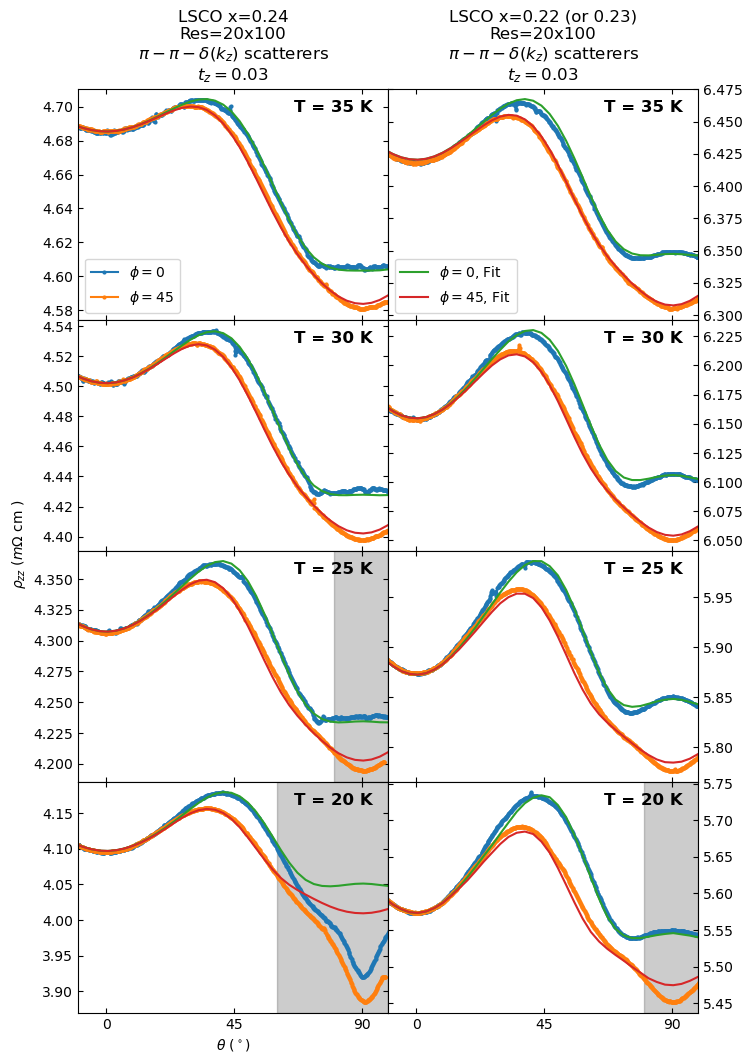

In [9]:
# FSorbitsInstance.plotpoints()
# Using gridspec_kw to remove vertical and horizontal spacing between subplots
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(8, 12), sharex=True, gridspec_kw={'wspace': 0, 'hspace': 0})

fits  =[   (percent24.fit_theta_35K, percent24.fit_phi0_35K, percent24.fit_phi45_35K),
    (percent24.fit_theta_30K, percent24.fit_phi0_30K, percent24.fit_phi45_30K),
    (percent24.fit_theta_25K, percent24.fit_phi0_25K, percent24.fit_phi45_25K),
    (percent24.fit_theta_20K, percent24.fit_phi0_20K, percent24.fit_phi45_20K)]


datas = [
    (percent24_data.data_theta_phi0_35K, percent24_data.data_phi0_35K, percent24_data.data_theta_phi45_35K, percent24_data.data_phi45_35K),
    (percent24_data.data_theta_phi0_30K, percent24_data.data_phi0_30K, percent24_data.data_theta_phi45_30K, percent24_data.data_phi45_30K),
    (percent24_data.data_theta_phi0_25K, percent24_data.data_phi0_25K, percent24_data.data_theta_phi45_25K, percent24_data.data_phi45_25K),
    (percent24_data.data_theta_phi0_20K, percent24_data.data_phi0_20K, percent24_data.data_theta_phi45_20K, percent24_data.data_phi45_20K)
]

axvspans = [None, None, (80, 99), (60, 99)]
temps = [35, 30, 25, 20]

for i in range(4):

    # Temperature text top right of left column
    axes[i,0].text(0.95, 0.95, f"T = {temps[i]} K", transform=axes[i,0].transAxes, fontsize=12, fontweight='bold', ha='right', va='top')
    
    # Data (Column 1)
    theta0_dat, phi0_dat, theta45_dat, phi45_dat = datas[i]
    lbl_0 = r"$\phi=0$" if i == 0 else None
    lbl_45 = r"$\phi=45$" if i == 0 else None
    axes[i,0].plot(theta0_dat, phi0_dat, ls="-", marker="o", ms=2, label=lbl_0)
    axes[i,0].plot(theta45_dat, phi45_dat, ls="-", marker="o", ms=2, label=lbl_45)

    # Model (Column 0)
    theta_fit, phi0_fit, phi45_fit = fits[i]
    axes[i,0].plot(theta_fit, phi0_fit, ls="-")
    axes[i,0].plot(theta_fit, phi45_fit, ls="-")
    
    # Axvspan applies to Row 2 and Row 3 Data
    if axvspans[i]:
        axes[i,0].axvspan(axvspans[i][0], axvspans[i][1], alpha=0.2, color='black')

    # Formatting for all plots in current row
    axes[i,0].tick_params(direction='in', right=True, top=True)


fits  =[   (percent22.fit_theta_35K, percent22.fit_phi0_35K, percent22.fit_phi45_35K),
    (percent22.fit_theta_30K, percent22.fit_phi0_30K, percent22.fit_phi45_30K),
    (percent22.fit_theta_25K, percent22.fit_phi0_25K, percent22.fit_phi45_25K),
    (percent22.fit_theta_20K, percent22.fit_phi0_20K, percent22.fit_phi45_20K)]


datas = [
    (percent22_data.data_theta_phi0_35K, percent22_data.data_phi0_35K, percent22_data.data_theta_phi45_35K, percent22_data.data_phi45_35K),
    (percent22_data.data_theta_phi0_30K, percent22_data.data_phi0_30K, percent22_data.data_theta_phi45_30K, percent22_data.data_phi45_30K),
    (percent22_data.data_theta_phi0_25K, percent22_data.data_phi0_25K, percent22_data.data_theta_phi45_25K, percent22_data.data_phi45_25K),
    (percent22_data.data_theta_phi0_20K, percent22_data.data_phi0_20K, percent22_data.data_theta_phi45_20K, percent22_data.data_phi45_20K)
]

axvspans = [None, None, None, (80, 99)]
temps = [35, 30, 25, 20]

for i in range(4):

    # Temperature text top right of left column
    axes[i,1].text(0.95, 0.95, f"T = {temps[i]} K", transform=axes[i,1].transAxes, fontsize=12, fontweight='bold', ha='right', va='top')

    # Data (Column 1)
    theta0_dat, phi0_dat, theta45_dat, phi45_dat = datas[i]
    lbl_0 = r"$\phi=0$, Fit" if i == 0 else None
    lbl_45 = r"$\phi=45$, Fit" if i == 0 else None
    axes[i,1].plot(theta0_dat, phi0_dat, ls="-", marker="o", ms=2)
    axes[i,1].plot(theta45_dat, phi45_dat, ls="-", marker="o", ms=2)

    # Model (Column 0)
    theta_fit, phi0_fit, phi45_fit = fits[i]
    axes[i,1].plot(theta_fit, phi0_fit, ls="-", label=lbl_0)
    axes[i,1].plot(theta_fit, phi45_fit, ls="-", label=lbl_45)

    # Axvspan applies to Row 2 and Row 3 Data
    if axvspans[i]:
        axes[i,1].axvspan(axvspans[i][0], axvspans[i][1], alpha=0.2, color='black')

    # Formatting for all plots in current row
    axes[i,1].tick_params(direction='in', right=True, top=True,labelright=True, labelleft=False)

    #putting ticklabels on right side
    axes[i,1].yaxis.set_label_position("right")

# Y-label essentially in the middle of left sideY-label essentially in the middle of left side
fig.text(0.04, 0.5, r"$\rho_{zz}$ ($m\Omega$ cm )", va='center', rotation='vertical')

# X-axis label only for the bottom row and setting specific x-ticks
axes[3,0].set_xlabel(r'$\theta$ ($^\circ$)')
axes[3,0].set_xlabel(r'$\theta$ ($^\circ$)')
axes[3,0].set_xticks([0, 45, 90])
axes[3,0].set_xticks([0, 45, 90])

# global plotting decoration
axes[0,0].set_title(f"LSCO x=0.24\nRes={20}x{100}\n$\pi-\pi-\delta(k_z)$ scatterers\n$t_z = 0.03$", fontsize=12)
axes[0,1].set_title(f"LSCO x=0.22 (or 0.23)\nRes={20}x{100}\n$\pi-\pi-\delta(k_z)$ scatterers\n$t_z = 0.03$", fontsize=12)
axes[0,0].legend(loc="lower left")
axes[0,1].legend(loc="lower left")

axes[0,0].set_xlim(-10,99)

# Removed plt.tight_layout() because manual gridspec_kw handles tight packing
plt.show()

In [10]:
def create_rho_24(params,Bmag):
    res_z = 20
    res_xy = 100

    mumultvalue=0.81

    Tzmultvalue,invtau_iso,strength,spread_xy,n = params

    plotScattering=False

    dispersionInstance = dispersion.LSCOdispersion(T= 190e-3,T1multvalue=-0.132,T11multvalue=0.066,Tzmultvalue=Tzmultvalue,mumultvalue=mumultvalue)
    FSorbitsInstance = orbitcreation.fermiSurfaceOrbits(res_z,res_xy,dispersionInstance,True)
    FSorbitsInstance.createFS(tilingformat="variable",alpha=0.1,parallelised=False)
    FSorbitsInstance.calculateDoping()

    conductivityInstance = conductivity.Conductivity(dispersionInstance,FSorbitsInstance,invtau_iso=invtau_iso,delta_in_k=True)
    conductivityInstance.createAmatrix_Bindependent_isotropic()
    conductivityInstance.create_Hfunc(scatteringmodel="pipidelta",strength=strength,spread_xy=spread_xy,n=n)
    conductivityInstance.createAmatrix_Bindependent_fwdscatter_out()
    conductivityInstance.createAmatrix_Bindependent_fwdscatter_in()

    theta=0
    phi_rad=0
    B = [Bmag*np.sin(np.deg2rad(theta))*np.cos(phi_rad),Bmag*np.sin(np.deg2rad(theta))*np.sin(phi_rad),Bmag*np.cos(np.deg2rad(theta))]

    conductivityInstance.createAmatrix_Bdependent(B)
    conductivityInstance.createAlpha()
    conductivityInstance.createSigma()

    rho = np.linalg.inv(conductivityInstance.sigma)

    return rho

def create_rho_22(params,Bmag):
    res_z = 20
    res_xy = 100

    mumultvalue=0.80

    Tzmultvalue,invtau_iso,strength,spread_xy,n = params

    plotScattering=False

    dispersionInstance = dispersion.LSCOdispersion(T= 190e-3,T1multvalue=-0.132,T11multvalue=0.066,Tzmultvalue=Tzmultvalue,mumultvalue=mumultvalue)
    FSorbitsInstance = orbitcreation.fermiSurfaceOrbits(res_z,res_xy,dispersionInstance,True)
    FSorbitsInstance.createFS(tilingformat="variable",alpha=0.1,parallelised=False)
    FSorbitsInstance.calculateDoping()

    conductivityInstance = conductivity.Conductivity(dispersionInstance,FSorbitsInstance,invtau_iso=invtau_iso,delta_in_k=True)
    conductivityInstance.createAmatrix_Bindependent_isotropic()
    conductivityInstance.create_Hfunc(scatteringmodel="pipidelta_exp",strength=strength,spread_xy=spread_xy,n=n)
    conductivityInstance.createAmatrix_Bindependent_fwdscatter_out()
    conductivityInstance.createAmatrix_Bindependent_fwdscatter_in()

    theta=0
    phi_rad=0
    B = [Bmag*np.sin(np.deg2rad(theta))*np.cos(phi_rad),Bmag*np.sin(np.deg2rad(theta))*np.sin(phi_rad),Bmag*np.cos(np.deg2rad(theta))]

    conductivityInstance.createAmatrix_Bdependent(B)
    conductivityInstance.createAlpha()
    conductivityInstance.createSigma()

    rho = np.linalg.inv(conductivityInstance.sigma)

    return rho

In [11]:
class rho24:
    temps = [20,25,30,35]
    rhoxx = np.array([create_rho_24(params,0)[0,0] for params in params24.paramslist])*10e-2
    rhoxy = np.array([create_rho_24(params,9)[0,1] for params in params24.paramslist])*10e-2

class rho22:
    temps = [20,25,30,35]
    rhoxx = np.array([create_rho_22(params,0)[0,0] for params in params22.paramslist])*10e-2
    rhoxy = np.array([create_rho_22(params,9)[0,1] for params in params22.paramslist])*10e-2

Doping = 0.2381407503670706%
Doping = 0.238162124116294%
Doping = 0.23824020703153237%
Doping = 0.2382961584797436%
Doping = 0.2381407503670706%
Doping = 0.238162124116294%
Doping = 0.23824020703153237%
Doping = 0.2382961584797436%
Doping = 0.230281238402553%
Doping = 0.23038149111112072%
Doping = 0.23044417352992064%
Doping = 0.2305023186637869%
Doping = 0.230281238402553%
Doping = 0.23038149111112072%
Doping = 0.23044417352992064%
Doping = 0.2305023186637869%


In [12]:
class data_rho24:
    temp_xx,rho_xx = np.loadtxt(repository_directory+f"data\ppms_data\LSCO_x=0.24_rho_xx_vs_T.csv",unpack=True,skiprows=1,delimiter=",")
    temp_xy,rho_xy = np.loadtxt(repository_directory+f"data\ppms_data\LSCO_x=0.24_rho_xy_vs_T.csv",unpack=True,skiprows=1,delimiter=",")

class data_rho22:
    temp_xx,rho_xx = np.loadtxt(repository_directory+f"data\ppms_data\LSCO_x=0.22_rho_xx_vs_T.csv",unpack=True,skiprows=1,delimiter=",")
    temp_xy,rho_xy = np.loadtxt(repository_directory+f"data\ppms_data\LSCO_x=0.22_rho_xy_vs_T.csv",unpack=True,skiprows=1,delimiter=",")

<>:2: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:3: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:6: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:7: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:2: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:3: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:6: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not w

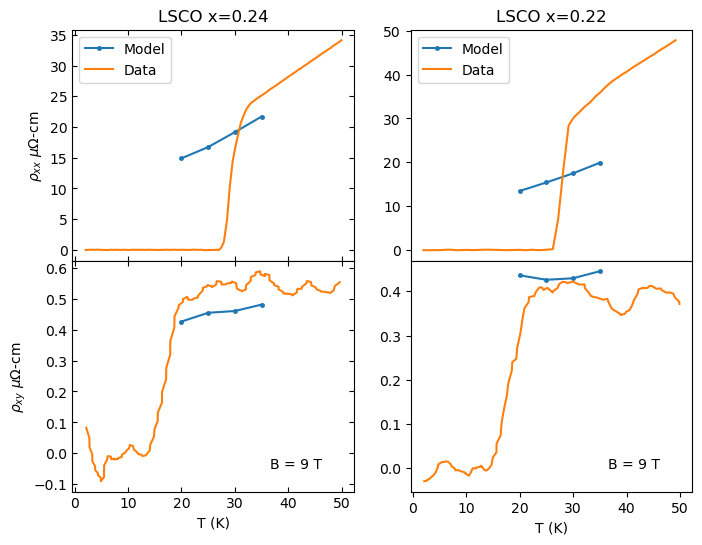

In [13]:
fig,axes_matrix = plt.subplots(nrows=2,ncols=2,figsize=(8,6), sharex=True, gridspec_kw={'hspace': 0})
axes = axes_matrix[:,0]
second_column_of_axes = axes_matrix[:,1]

axes[0].plot(rho24.temps,rho24.rhoxx,marker=".",ms=5,ls="-", label="Model")
axes[0].plot(data_rho24.temp_xx[data_rho24.temp_xx<50],data_rho24.rho_xx[data_rho24.temp_xx<50],ls="-", label="Data")
axes[0].set_ylabel(r"$\rho_{xx}$ $\mu\Omega$-cm")
axes[0].legend()

axes[1].plot(rho24.temps,rho24.rhoxy,marker=".",ms=5,ls="-")
axes[1].plot(data_rho24.temp_xy[data_rho24.temp_xy<50],data_rho24.rho_xy[data_rho24.temp_xy<50],ls="-")
axes[1].set_ylabel(r"$\rho_{xy}$ $\mu\Omega$-cm")
axes[1].text(0.7,0.1,"B = 9 T",transform=axes[1].transAxes)
axes[1].set_xlabel("T (K)")

second_column_of_axes[0].plot(rho22.temps,rho22.rhoxx,marker=".",ms=5,ls="-", label="Model")
second_column_of_axes[0].plot(data_rho22.temp_xx[data_rho22.temp_xx<50],data_rho22.rho_xx[data_rho22.temp_xx<50],ls="-", label="Data")
second_column_of_axes[0].legend()
second_column_of_axes[1].plot(rho22.temps,rho22.rhoxy,marker=".",ms=5,ls="-")
second_column_of_axes[1].plot(data_rho22.temp_xy[data_rho22.temp_xy<50],data_rho22.rho_xy[data_rho22.temp_xy<50],ls="-")
second_column_of_axes[1].text(0.7,0.1,"B = 9 T",transform=second_column_of_axes[1].transAxes)
second_column_of_axes[1].set_xlabel("T (K)")

axes[0].set_title("LSCO x=0.24")
second_column_of_axes[0].set_title("LSCO x=0.22")

for ax in axes:
    ax.tick_params(direction='in', right=True, top=True)


In [14]:
def create_data(params):

    starttime_global = time()
    thetalist = np.linspace(-14,99,40)

    res_z = 20
    res_xy = 100

    mumultvalue=0.805

    Tzmultvalue,invtau_iso,strength,spread_xy,n = params

    plotScattering=False

    dispersionInstance = dispersion.LSCOdispersion(T= 190e-3,T1multvalue=-0.134,T11multvalue=0.067,Tzmultvalue=Tzmultvalue,mumultvalue=mumultvalue)
    FSorbitsInstance = orbitcreation.fermiSurfaceOrbits(res_z,res_xy,dispersionInstance,True)
    starttime = time()
    FSorbitsInstance.createFS(tilingformat="variable",alpha=0.1,parallelised=False)
    endtime = time()
    print(f"Time taken to create Fermi Surface = {endtime - starttime}")
    print(f"Doping={FSorbitsInstance.calculateDoping()}")

    def create_rhozz(phi,Bmag,scattering_in=True):
        phi_rad = np.deg2rad(phi)
        conductivityInstance = conductivity.Conductivity(dispersionInstance,FSorbitsInstance,invtau_iso=invtau_iso,delta_in_k=True)
        starttime = time()
        conductivityInstance.createAmatrix_Bindependent_isotropic()
        conductivityInstance.create_Hfunc(scatteringmodel="pipidelta_exp",strength=strength,spread_xy=spread_xy,n=n)
        conductivityInstance.createAmatrix_Bindependent_fwdscatter_out()
        if scattering_in: conductivityInstance.createAmatrix_Bindependent_fwdscatter_in()
        endtime = time()
        print(f"Time taken to create B independent Amatrix =  {endtime - starttime}")

        def getsigma(theta,Bmag=Bmag):
            B = [Bmag*np.sin(np.deg2rad(theta))*np.cos(phi_rad),Bmag*np.sin(np.deg2rad(theta))*np.sin(phi_rad),Bmag*np.cos(np.deg2rad(theta))]
            conductivityInstance.createAmatrix_Bdependent(B)
            conductivityInstance.createAlpha()
            conductivityInstance.createSigma()

            #print(f"Theta={theta}. Calculated total area: {conductivityInstance.areasum}. Number of orbits used {len(conductivityInstance.FSorbitsInstance.FSorbits)}. Size of Amatrix: {conductivityInstance.n}")
            return conductivityInstance.sigma,conductivityInstance.areasum


        sigmalist,rholist,arealist = makelist_parallel(getsigma,thetalist)
        #sigma_zero,area_zero = getsigma(theta=0,Bmag=0)
        #sigma_9T,area_9T = getsigma(theta=0,Bmag=9)

        #rho_zero = np.linalg.inv(sigma_zero)
        #rho_9T = np.linalg.inv(sigma_9T)

        rhozzlist= [rho[2,2]*10e-5 for rho in rholist]
        #print(f"rho_xx = {rho_zero[0,0]*10e-2}, rho_xy (9 T) = {rho_9T[0,1]*10e-2}")

        endtime_global = time()
        print(f"execution time: {endtime_global-starttime_global}")

        return rhozzlist

    #generate data
    rhozzlist0 = create_rhozz(phi=0,Bmag=45,scattering_in=True)
    rhozzlist45 = create_rhozz(phi=45,Bmag=45,scattering_in=True)

    return rhozzlist0,rhozzlist45,thetalist


In [15]:
data_theta_phi0_30K_22perc,data_phi0_30K_22perc = np.loadtxt(repository_directory+"data/admr_data/2601C/2601C_phi0_T30K_B45.0T.txt",unpack=True,skiprows=1,delimiter=",",usecols=(0,1))
data_theta_phi45_30K_22perc,data_phi45_30K_22perc = np.loadtxt(repository_directory+"data/admr_data/2601C/2601C_phi45_T30K_B45.0T.txt",unpack=True,skiprows=1,delimiter=",",usecols=(0,1))

fit_phi0_30K_22perc,fit_phi45_30K_22perc,fit_theta_30K_22perc = create_data((0.03052,7.7,13.5,0.1523052248981892,7.694942153701261))

Time taken to create Fermi Surface = 0.055899858474731445
Doping = 0.22818195871982705%
Doping=0.22818195871982705
Time taken to create B independent Amatrix =  0.403958797454834
execution time: 1.8678524494171143
Time taken to create B independent Amatrix =  0.387951135635376
execution time: 3.5310020446777344


In [16]:
red = "#D95F5F"
dark_red = "#A94444"

blue = "#4C78A8"
dark_blue = "#345578"

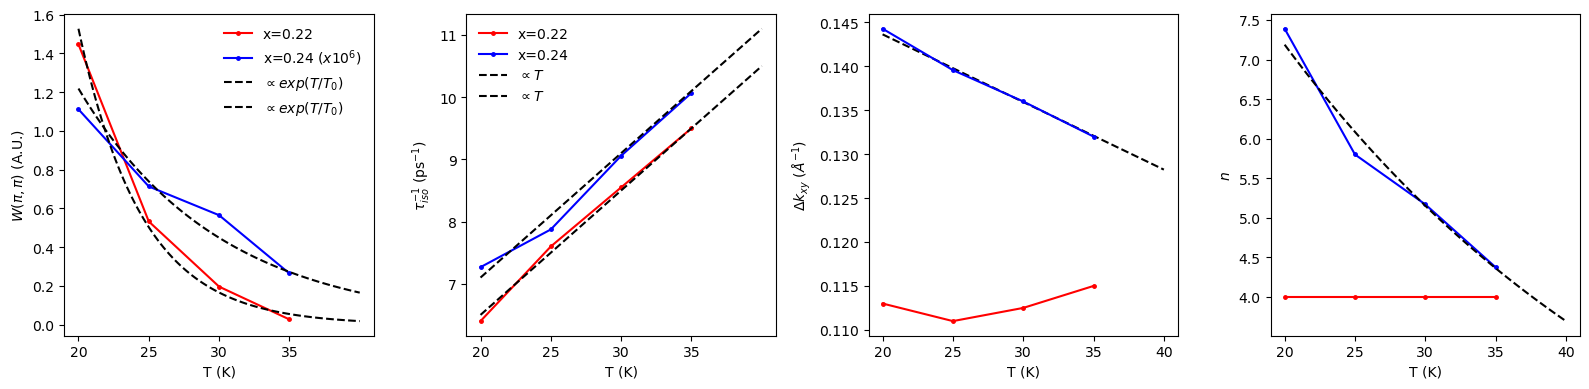

In [17]:
peak_22perc = np.exp(params22.paramslist[:,2])
peak_24perc = params24.paramslist[:,2]

iso_22perc = params22.paramslist[:,1]
iso_24perc = params24.paramslist[:,1]

width_22perc = params22.paramslist[:,3]
width_24perc = params24.paramslist[:,3]

n_22perc = params22.paramslist[:,4]
n_24perc = params24.paramslist[:,4]


temps = [20,25,30,35]

fit_temps = np.linspace(20,40,100)

fig,(axes,axes_iso,axes_width,axes_n) = plt.subplots(nrows=1,ncols=4,figsize=(16,4))

axes.plot(temps,peak_22perc/1e12,marker=".",ms=5,ls="-",label="x=0.22",color='red')
axes.plot(temps,peak_24perc/1e6,marker=".",ms=5,ls="-",label=r"x=0.24 ($x10^{6}$)",color='blue')
axes.plot(fit_temps,130*np.exp(-fit_temps/4.5),ls="--",color='black',label=r"$\propto exp(T/T_0)$")
axes.plot(fit_temps,9*np.exp(-fit_temps/10),ls="--",color='black',label=r"$\propto exp(T/T_0)$")
axes.set_xlabel("T (K)")
axes.set_ylabel(r"$W(\pi,\pi)$ (A.U.)")

axes_iso.plot(temps,iso_22perc,marker=".",ms=5,ls="-",label="x=0.22",color='red')
axes_iso.plot(temps,iso_24perc,marker=".",ms=5,ls="-",label=r"x=0.24",color='blue')
axes_iso.plot(fit_temps,fit_temps/5+2.5,ls="--",color='black',label=r"$\propto T$")
axes_iso.plot(fit_temps,fit_temps/5+3.1,ls="--",color='black',label=r"$\propto T$")
axes_iso.set_xlabel("T (K)")
axes_iso.set_ylabel(r"$\tau_{iso}^{-1}$ (ps$^{-1}$)")

axes_width.plot(temps,width_22perc,marker=".",ms=5,ls="-",label="x=0.22",color='red')
axes_width.plot(fit_temps,0.159-fit_temps/1300,ls="--",color='black',label=r"$\propto exp(T/T_0)$")
axes_width.plot(temps,width_24perc,marker=".",ms=5,ls="-",label=r"x=0.24",color='blue')
axes_width.set_xlabel("T (K)")
axes_width.set_ylabel(r"$\Delta k_{xy}$ ($\AA^{-1}$)")

axes_n.plot(temps,n_22perc,marker=".",ms=5,ls="-",label="x=0.22",color='red')
axes_n.plot(temps,n_24perc,marker=".",ms=5,ls="-",label=r"x=0.24",color='blue')
axes_n.plot(fit_temps,14*np.exp(-fit_temps/30),ls="--",color='black',label=r"$\propto exp(T/T_0)$")
axes_n.set_xlabel("T (K)")
axes_n.set_ylabel(r"$n$")

axes.set_xticks([20,25,30,35])
axes_iso.set_xticks([20,25,30,35])
axes.legend(loc="upper right",fontsize=10,frameon=False)
axes_iso.legend(loc="upper left",fontsize=10,frameon=False)
fig.tight_layout()
fig.savefig("pipiscattering_for_proposal.png",dpi=300,bbox_inches='tight')


In [18]:
extrapolated_temps = np.linspace(20,300,45)
extrapolated_strength = 130*np.exp(-extrapolated_temps/4.5)
extrapolated_invtau_iso = extrapolated_temps/5+2.5
extrapolated_spread_xy = 0.112*np.ones_like(extrapolated_temps)
extrapolated_n = 4*np.ones_like(extrapolated_temps)
tzmultvalue = 0.03*np.ones_like(extrapolated_temps)

rhoxx_22_extrapolated = np.zeros_like(extrapolated_temps)

for i in range(len(extrapolated_temps)):
    rho = create_rho_22((tzmultvalue[i],extrapolated_invtau_iso[i],extrapolated_strength[i],extrapolated_spread_xy[i],extrapolated_n[i]),Bmag=0)
    rhoxx_22_extrapolated[i] = rho[0,0]*10e-2

Doping = 0.23050300077936314%
Doping = 0.23050300077936314%
Doping = 0.23050300077936314%
Doping = 0.23050300077936314%
Doping = 0.23050300077936314%
Doping = 0.23050300077936314%
Doping = 0.23050300077936314%
Doping = 0.23050300077936314%
Doping = 0.23050300077936314%
Doping = 0.23050300077936314%
Doping = 0.23050300077936314%
Doping = 0.23050300077936314%
Doping = 0.23050300077936314%
Doping = 0.23050300077936314%
Doping = 0.23050300077936314%
Doping = 0.23050300077936314%
Doping = 0.23050300077936314%
Doping = 0.23050300077936314%
Doping = 0.23050300077936314%
Doping = 0.23050300077936314%
Doping = 0.23050300077936314%
Doping = 0.23050300077936314%
Doping = 0.23050300077936314%
Doping = 0.23050300077936314%
Doping = 0.23050300077936314%
Doping = 0.23050300077936314%
Doping = 0.23050300077936314%
Doping = 0.23050300077936314%
Doping = 0.23050300077936314%
Doping = 0.23050300077936314%
Doping = 0.23050300077936314%
Doping = 0.23050300077936314%
Doping = 0.23050300077936314%
Doping = 0

In [19]:
extrapolated_temps = np.linspace(20,300,45)
extrapolated_strength = 9*np.exp(-extrapolated_temps/10)
extrapolated_invtau_iso = extrapolated_temps/5+3.1
extrapolated_spread_xy = 0.159-extrapolated_temps/1300
extrapolated_n = 14*np.exp(-extrapolated_temps/30)
tzmultvalue = 0.03*np.ones_like(extrapolated_temps)

rhoxx_24_extrapolated = np.zeros_like(extrapolated_temps)

for i in range(len(extrapolated_temps)):
    rho = create_rho_24((tzmultvalue[i],extrapolated_invtau_iso[i],extrapolated_strength[i],extrapolated_spread_xy[i],extrapolated_n[i]),Bmag=0)
    rhoxx_24_extrapolated[i] = rho[0,0]*10e-2

Doping = 0.23806511492561278%
Doping = 0.23806511492561278%
Doping = 0.23806511492561278%
Doping = 0.23806511492561278%
Doping = 0.23806511492561278%
Doping = 0.23806511492561278%
Doping = 0.23806511492561278%
Doping = 0.23806511492561278%
Doping = 0.23806511492561278%
Doping = 0.23806511492561278%
Doping = 0.23806511492561278%
Doping = 0.23806511492561278%
Doping = 0.23806511492561278%
Doping = 0.23806511492561278%
Doping = 0.23806511492561278%
Doping = 0.23806511492561278%
Doping = 0.23806511492561278%
Doping = 0.23806511492561278%
Doping = 0.23806511492561278%
Doping = 0.23806511492561278%
Doping = 0.23806511492561278%
Doping = 0.23806511492561278%
Doping = 0.23806511492561278%
Doping = 0.23806511492561278%
Doping = 0.23806511492561278%
Doping = 0.23806511492561278%
Doping = 0.23806511492561278%
Doping = 0.23806511492561278%
Doping = 0.23806511492561278%
Doping = 0.23806511492561278%
Doping = 0.23806511492561278%
Doping = 0.23806511492561278%
Doping = 0.23806511492561278%
Doping = 0

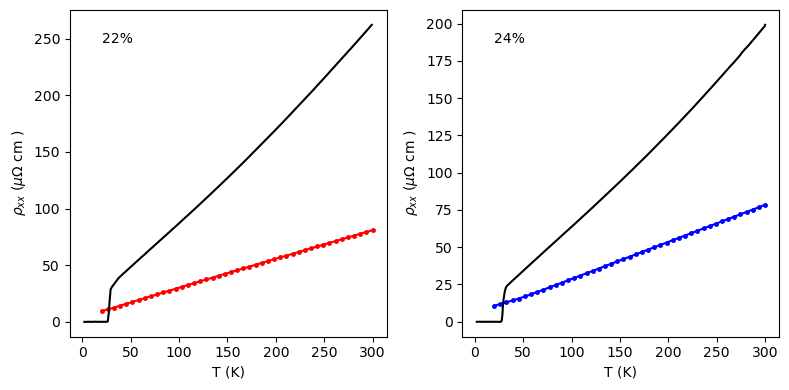

In [20]:
fig,axes = plt.subplots(nrows=1,ncols=2,figsize=(8,4))
axes[0].plot(extrapolated_temps,rhoxx_22_extrapolated,marker=".",ms=5,ls="-",label="x=0.22",color='red')
axes[0].plot(data_rho22.temp_xx[data_rho22.temp_xx<300],data_rho22.rho_xx[data_rho22.temp_xx<300],ls="-", label="Data",color='black')
axes[0].set_xlabel("T (K)")
axes[0].set_ylabel(r"$\rho_{xx}$ ($\mu\Omega$ cm )")
axes[0].text(0.1,0.9,"22%",transform=axes[0].transAxes)

axes[1].plot(extrapolated_temps,rhoxx_24_extrapolated,marker=".",ms=5,ls="-",label="x=0.24",color='blue')
axes[1].plot(data_rho24.temp_xx[data_rho24.temp_xx<300],data_rho24.rho_xx[data_rho24.temp_xx<300],ls="-", label="Data",color='black')
axes[1].set_xlabel("T (K)")
axes[1].set_ylabel(r"$\rho_{xx}$ ($\mu\Omega$ cm )")
axes[1].text(0.1,0.9,"24%",transform=axes[1].transAxes)

fig.tight_layout()

In [77]:
#22% plots for different scattering strengths

theta_min,theta_max,n_thetas = -14,99,20
thetalist = np.sort(np.concatenate([np.linspace(theta_min,theta_max,n_thetas),[0]])) #list of 20 numbers from -14 to 99 but 0 is forced in there

#original fit params
params=(0.02663,6.4,28,0.113,4)
fit_phi0_20K,fit_phi45_20K,fit_theta_20K = create_data_22(params)

#scattering strength from 35K, same z axis + same isotropic
params35K=(0.02663,6.4,24,0.115,4)
fit_phi0_35Kparams,fit_phi45_35Kparams,fit_theta_35Kparams = create_data_22(params35K)

#scattering strength from 24percent sample at same temperature
params24perc = (0.02663,6.4,13.92065,0.14425692694831663,7.389590020484316)
fit_phi0_24perc,fit_phi45_24perc,fit_theta_24perc = create_data_22(params24perc)

#scattering strength from 24percent sample at same temperature
params_small = (0.02663,6.4,4,0.14425692694831663,7.389590020484316)
fit_phi0_small,fit_phi45_small,fit_theta_small = create_data_22(params_small)

#data at 20K for 22percent
data_theta_phi0_20K,data_phi0_20K = np.loadtxt(repository_directory+"data/admr_data/2601C/2601C_phi0_T20K_B45.0T.txt",unpack=True,skiprows=1,delimiter=",",usecols=(0,1))
data_theta_phi45_20K ,data_phi45_20K= np.loadtxt(repository_directory+"data/admr_data/2601C/2601C_phi45_T20K_B45.0T.txt",unpack=True,skiprows=1,delimiter=",",usecols=(0,1))

Time taken to create Fermi Surface = 0.055381059646606445
Doping = 0.230281238402553%
Doping=0.230281238402553
Time taken to create B independent Amatrix =  0.4335908889770508
execution time: 2.2197985649108887
Time taken to create B independent Amatrix =  0.42371582984924316
execution time: 4.220236778259277
Time taken to create Fermi Surface = 0.05978059768676758
Doping = 0.230281238402553%
Doping=0.230281238402553
Time taken to create B independent Amatrix =  0.411207914352417
execution time: 2.1526551246643066
Time taken to create B independent Amatrix =  0.45310044288635254
execution time: 4.2105019092559814
Time taken to create Fermi Surface = 0.06059908866882324
Doping = 0.230281238402553%
Doping=0.230281238402553
Time taken to create B independent Amatrix =  0.44466209411621094
execution time: 1.9396083354949951
Time taken to create B independent Amatrix =  0.4105498790740967
execution time: 3.992255926132202
Time taken to create Fermi Surface = 0.06484627723693848
Doping = 0.2

In [78]:
rho = create_rho_22(params=params,Bmag=0)[0,0]*10e-2
rho_35K = create_rho_22(params=params35K,Bmag=0)[0,0]*10e-2
rho_24perc = create_rho_22(params=params24perc,Bmag=0)[0,0]*10e-2
rho_small = create_rho_22(params=params_small,Bmag=0)[0,0]*10e-2

Doping = 0.230281238402553%
Doping = 0.230281238402553%
Doping = 0.230281238402553%
Doping = 0.230281238402553%


Text(0.5, 0, '$\\theta$')

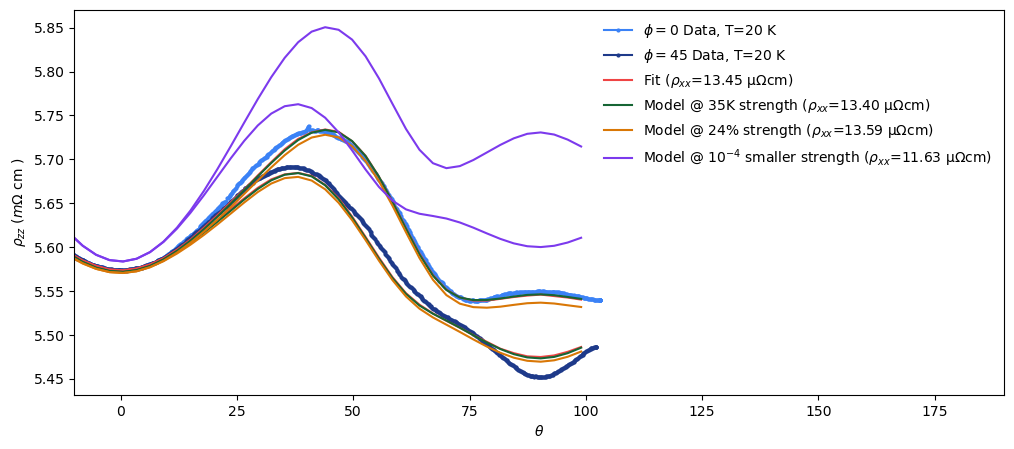

In [83]:
fig,axes = plt.subplots(nrows=1,ncols=1, figsize=(12, 5))

axes.set_xlim(-10,190)

axes.plot(data_theta_phi0_20K,data_phi0_20K, ls="-", marker="o", ms=2, label=r"$\phi=0$ Data, T=20 K",color="#3B82F6")
axes.plot(data_theta_phi45_20K,data_phi45_20K, ls="-", marker="o", ms=2, label=r"$\phi=45$ Data, T=20 K",color="#1E3A8A")

axes.plot(fit_theta_20K, fit_phi0_20K, ls="-", label=f"Fit ($ρ_{{xx}}$={rho:.2f} μΩcm)",color="#EF4444")
axes.plot(fit_theta_20K, fit_phi45_20K, ls="-",color="#EF4444")

axes.plot(fit_theta_35Kparams, fit_phi0_35Kparams, ls="-", label=f"Model @ 35K strength ($ρ_{{xx}}$={rho_35K:.2f} μΩcm)",color="#166534")
axes.plot(fit_theta_35Kparams, fit_phi45_35Kparams, ls="-",color="#166534")

axes.plot(fit_theta_24perc, fit_phi0_24perc, ls="-", label=f"Model @ 24% strength ($ρ_{{xx}}$={rho_24perc:.2f} μΩcm)",color="#D97706")
axes.plot(fit_theta_24perc, fit_phi45_24perc, ls="-",color="#D97706")

axes.plot(fit_theta_small, fit_phi0_small, ls="-", label=f"Model @ $10^{{-4}}$ smaller strength ($ρ_{{xx}}$={rho_small:.2f} μΩcm)", color="#7C3AED")
axes.plot(fit_theta_small, fit_phi45_small, ls="-", color="#7C3AED")

axes.legend(loc="upper right", frameon=False)

axes.set_ylabel(r"$\rho_{zz}$ ($m\Omega$ cm )") 
axes.set_xlabel(r'$\theta$')